In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

ZIP_PATH = 'terminal_encounter_state_data_20200630.zip'

COLUMNS = [
    'time', 'speed', 'track_angle', 'bank_angle', 'pitch_angle',
    'accel', 'pos_x', 'pos_y', 'alt', 'vel_x', 'vel_y',
    'vel_z', 'heading_rate', 'lat', 'lon'
]

def load_encounter_pair(zf, encounter_id):
    subdir_id = ((encounter_id - 1) // 1000) * 1000 + 1
    subdir = f'encounters_{subdir_id:06d}/'
    own_path = subdir + f'ownstates_{encounter_id:06d}.csv'
    int_path = subdir + f'intstates_{encounter_id:06d}.csv'

    with zf.open(own_path) as f:
        df_own = pd.read_csv(f, names=COLUMNS, skiprows=2, skip_blank_lines=True)
    with zf.open(int_path) as f:
        df_int = pd.read_csv(f, names=COLUMNS, skiprows=2, skip_blank_lines=True)

    return df_own, df_int

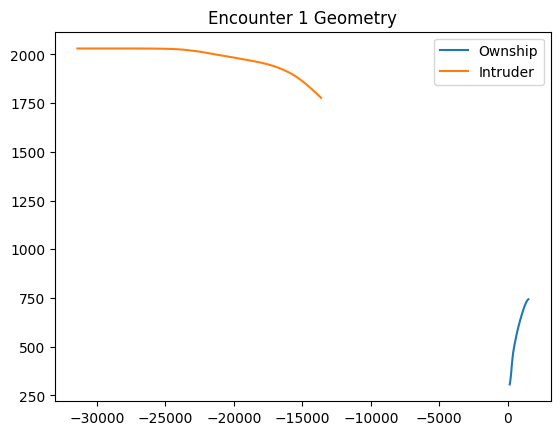

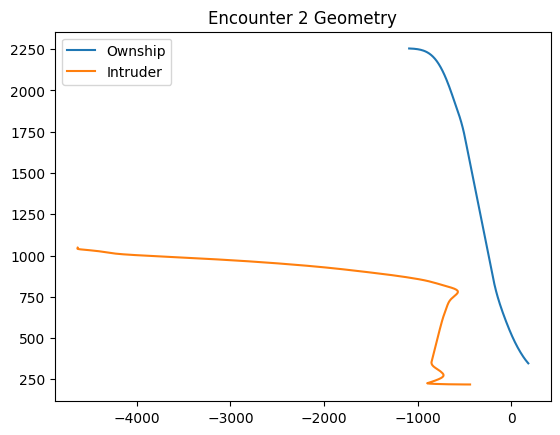

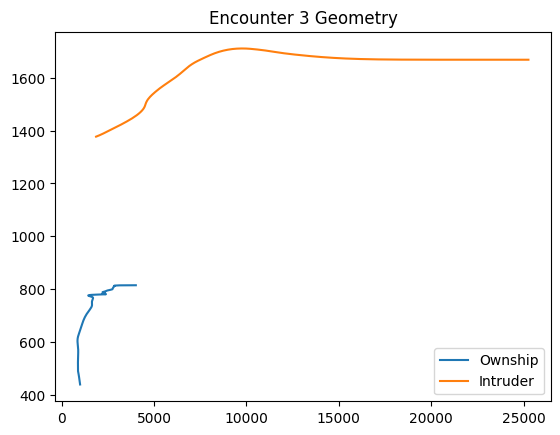

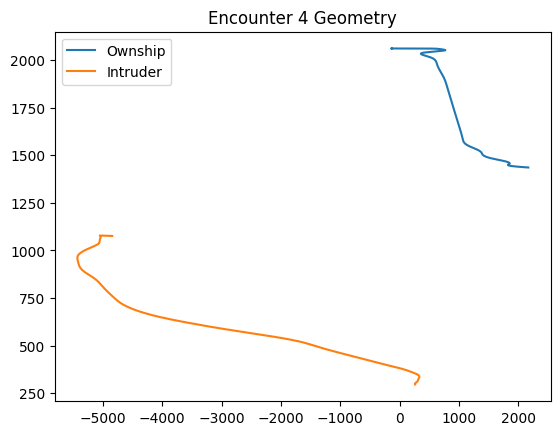

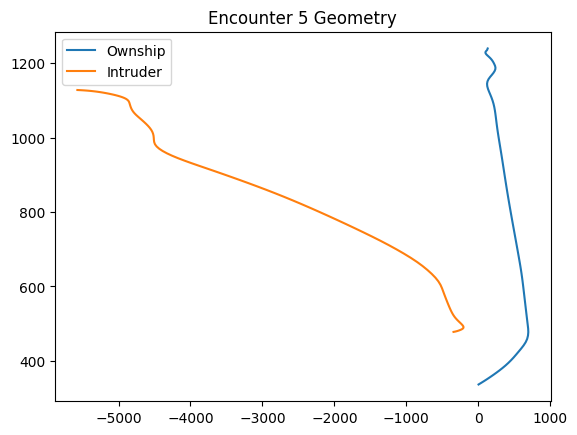

Mean Minimum Separation: 3515.15 ft


In [2]:
all_min_distances = []
all_bank_angles = []

with zipfile.ZipFile(ZIP_PATH) as zf:
    for i in range(1, 6):
        try:
            own, intruder = load_encounter_pair(zf, i)

            range_sq = (own['pos_x'] - intruder['pos_x'])**2 + (own['pos_y'] - intruder['pos_y'])**2
            dist = np.sqrt(range_sq)
            all_min_distances.append(dist.min())

            all_bank_angles.extend(own['bank_angle'].tolist())

            plt.figure()
            plt.plot(own['pos_x'], own['pos_y'], label='Ownship')
            plt.plot(intruder['pos_x'], intruder['pos_y'], label='Intruder')
            plt.title(f"Encounter {i} Geometry")
            plt.legend()
            plt.show()

        except Exception as e:
            print(f"Encounter {i} failed: {e}")

if all_min_distances:
    print(f"Mean Minimum Separation: {np.mean(all_min_distances):.2f} ft")
else:
    print("No encounters loaded.")

## Step 1: Verify Data Integrity and Completeness

In [3]:
INFO_PATH = 'terminal_encounter_info_20200630.csv'

# Load encounter metadata
info = pd.read_csv(INFO_PATH)
info.columns = info.columns.str.strip()  # remove leading/trailing spaces

# Count trajectory files in zip
with zipfile.ZipFile(ZIP_PATH) as zf:
    names = zf.namelist()
    n_own = sum(1 for n in names if 'ownstates' in n)
    n_int = sum(1 for n in names if 'intstates' in n)

print("=== Dataset Integrity Check ===")
print(f"Info CSV rows:       {len(info):>10,}")
print(f"Ownship files:       {n_own:>10,}")
print(f"Intruder files:      {n_int:>10,}")
print(f"Expected encounters: {1_000_000:>10,}")
print(f"Complete:            {'YES' if len(info) == n_own == n_int == 1_000_000 else 'NO'}")
print()
print("=== NaN Check (info CSV) ===")
nan_counts = info.isnull().sum()
print(nan_counts[nan_counts > 0] if nan_counts.any() else "No missing values found.")

=== Dataset Integrity Check ===
Info CSV rows:        1,000,000
Ownship files:        1,000,000
Intruder files:       1,000,000
Expected encounters:  1,000,000
Complete:            YES

=== NaN Check (info CSV) ===
No missing values found.


## Step 2: Review Dataset Documentation and Metadata

=== Encounter Conditions Summary ===
Intruder intent — Landing (1): 672,124  |  Takeoff (2): 327,876

       own_distance     own_alt   own_speed  int_distance     int_alt   int_speed      hmd_ft      vmd_ft       tcpa
count    1000000.00  1000000.00  1000000.00    1000000.00  1000000.00  1000000.00  1000000.00  1000000.00  1000000.0
mean           2.33      717.29      148.75          2.31     1065.64      170.32     6715.85      336.23      105.9
std            1.56      459.51       54.52          1.62      555.85       60.95     4729.85      579.47       31.4
min            0.00      200.00       75.00          0.00      200.00       75.00        0.86    -2660.60        0.0
25%            1.26      368.26      105.22          1.27      645.03      125.06     3442.77      -26.44      114.0
50%            1.89      578.17      139.70          1.91      994.54      169.08     5807.54      308.32      118.0
75%            2.85      940.67      186.94          2.90     1376.53      205.

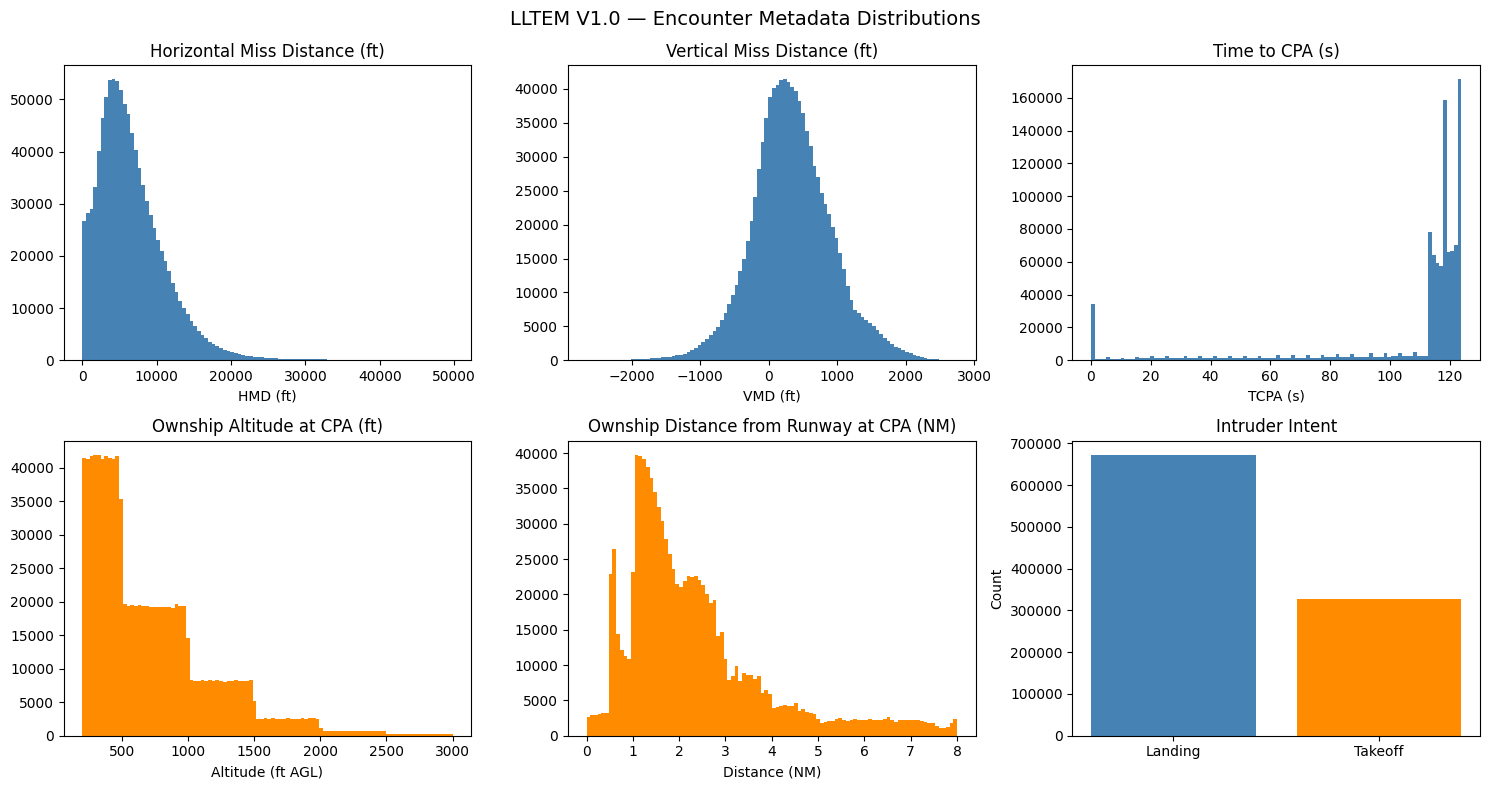

In [4]:
print("=== Encounter Conditions Summary ===")
print(f"Intruder intent — Landing (1): {(info['int_intent']==1).sum():,}  |  Takeoff (2): {(info['int_intent']==2).sum():,}")
print()
print(info[['own_distance', 'own_alt', 'own_speed', 'int_distance', 'int_alt', 'int_speed', 'hmd_ft', 'vmd_ft', 'tcpa']].describe().round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("LLTEM V1.0 — Encounter Metadata Distributions", fontsize=14)

axes[0,0].hist(info['hmd_ft'], bins=100, color='steelblue', edgecolor='none')
axes[0,0].set_title('Horizontal Miss Distance (ft)')
axes[0,0].set_xlabel('HMD (ft)')

axes[0,1].hist(info['vmd_ft'], bins=100, color='steelblue', edgecolor='none')
axes[0,1].set_title('Vertical Miss Distance (ft)')
axes[0,1].set_xlabel('VMD (ft)')

axes[0,2].hist(info['tcpa'], bins=100, color='steelblue', edgecolor='none')
axes[0,2].set_title('Time to CPA (s)')
axes[0,2].set_xlabel('TCPA (s)')

axes[1,0].hist(info['own_alt'], bins=100, color='darkorange', edgecolor='none')
axes[1,0].set_title('Ownship Altitude at CPA (ft)')
axes[1,0].set_xlabel('Altitude (ft AGL)')

axes[1,1].hist(info['own_distance'], bins=100, color='darkorange', edgecolor='none')
axes[1,1].set_title('Ownship Distance from Runway at CPA (NM)')
axes[1,1].set_xlabel('Distance (NM)')

axes[1,2].bar(['Landing', 'Takeoff'], [(info['int_intent']==1).sum(), (info['int_intent']==2).sum()],
              color=['steelblue', 'darkorange'])
axes[1,2].set_title('Intruder Intent')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Step 3: Identify Relevant Scenarios for Conflict Resolution Analysis

=== Conflict Scenario Filter (Well-Clear Violations) ===
HMD threshold:  < 1,500 ft
VMD threshold:  < 450 ft

Total encounters:           1,000,000
Conflict encounters:           60,929  (6.1%)
  — intruder landing:          50,912
  — intruder taking off:       10,017

Conflict encounter IDs saved to 'conflict_ids' (60,929 entries)


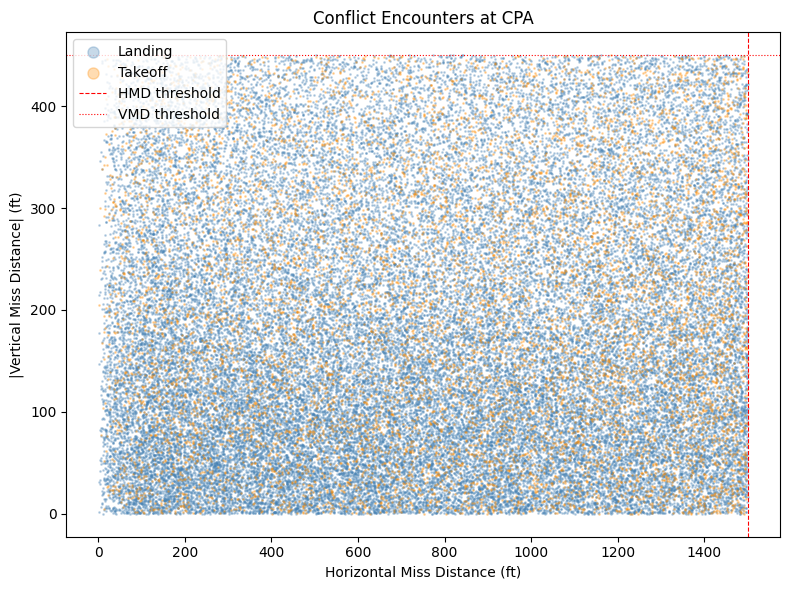

In [5]:
# Well-clear thresholds per DO-365A (ACAS Xu)
HMD_THRESHOLD_FT  = 1500   # terminal area
VMD_THRESHOLD_FT  = 450    # vertical

# A conflict scenario is one where CPA violates well-clear
conflicts = info[
    (info['hmd_ft'].abs() < HMD_THRESHOLD_FT) &
    (info['vmd_ft'].abs() < VMD_THRESHOLD_FT)
].copy()

# Break down by intruder intent
n_landing = (conflicts['int_intent'] == 1).sum()
n_takeoff  = (conflicts['int_intent'] == 2).sum()

print("=== Conflict Scenario Filter (Well-Clear Violations) ===")
print(f"HMD threshold:  < {HMD_THRESHOLD_FT:,} ft")
print(f"VMD threshold:  < {VMD_THRESHOLD_FT:,} ft")
print()
print(f"Total encounters:          {len(info):>10,}")
print(f"Conflict encounters:       {len(conflicts):>10,}  ({100*len(conflicts)/len(info):.1f}%)")
print(f"  — intruder landing:      {n_landing:>10,}")
print(f"  — intruder taking off:   {n_takeoff:>10,}")

# Save filtered IDs for downstream use
conflict_ids = conflicts['id'].values
print(f"\nConflict encounter IDs saved to 'conflict_ids' ({len(conflict_ids):,} entries)")

# Scatter: HMD vs VMD coloured by intruder intent
fig, ax = plt.subplots(figsize=(8, 6))
for intent, label, color in [(1, 'Landing', 'steelblue'), (2, 'Takeoff', 'darkorange')]:
    sub = conflicts[conflicts['int_intent'] == intent]
    ax.scatter(sub['hmd_ft'], sub['vmd_ft'].abs(), s=1, alpha=0.3, color=color, label=label)
ax.axvline(HMD_THRESHOLD_FT, color='red', linestyle='--', linewidth=0.8, label='HMD threshold')
ax.axhline(VMD_THRESHOLD_FT, color='red', linestyle=':',  linewidth=0.8, label='VMD threshold')
ax.set_xlabel('Horizontal Miss Distance (ft)')
ax.set_ylabel('|Vertical Miss Distance| (ft)')
ax.set_title('Conflict Encounters at CPA')
ax.legend(markerscale=8)
plt.tight_layout()
plt.show()

Simultaneous HMD and VMD Violations

=== Simultaneous Violation Breakdown ===
  Both HMD & VMD           60,929   (6.09%)
  HMD only                 23,421   (2.34%)
  VMD only                470,363   (47.04%)
  Neither                 445,287   (44.53%)


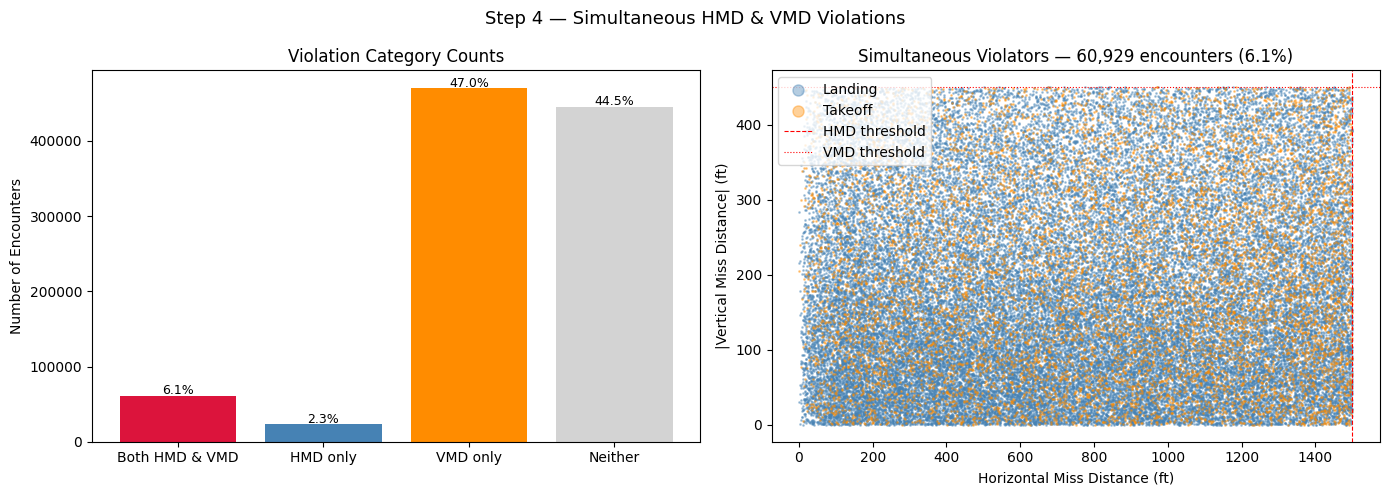

In [6]:
N = len(info)
hmd_viol = info['hmd_ft'].abs() < HMD_THRESHOLD_FT
vmd_viol = info['vmd_ft'].abs() < VMD_THRESHOLD_FT

both_mask  = hmd_viol & vmd_viol
hmd_only   = hmd_viol & ~vmd_viol
vmd_only   = ~hmd_viol & vmd_viol
neither    = ~hmd_viol & ~vmd_viol

categories = {
    'Both HMD & VMD': both_mask.sum(),
    'HMD only':       hmd_only.sum(),
    'VMD only':       vmd_only.sum(),
    'Neither':        neither.sum(),
}

print("=== Simultaneous Violation Breakdown ===")
for label, count in categories.items():
    print(f"  {label:<20} {count:>10,}   ({100*count/N:.2f}%)")

both = info[both_mask].copy()

# --- Plot 1: bar chart of the four categories ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 4 — Simultaneous HMD & VMD Violations", fontsize=13)

colors = ['crimson', 'steelblue', 'darkorange', 'lightgrey']
axes[0].bar(categories.keys(), categories.values(), color=colors)
axes[0].set_ylabel('Number of Encounters')
axes[0].set_title('Violation Category Counts')
for i, (label, count) in enumerate(categories.items()):
    axes[0].text(i, count + N*0.002, f'{100*count/N:.1f}%', ha='center', fontsize=9)

# --- Plot 2: HMD vs |VMD| scatter for simultaneous violators, coloured by intruder intent ---
for intent, label, color in [(1, 'Landing', 'steelblue'), (2, 'Takeoff', 'darkorange')]:
    sub = both[both['int_intent'] == intent]
    axes[1].scatter(sub['hmd_ft'], sub['vmd_ft'].abs(), s=1, alpha=0.4, color=color, label=label)

axes[1].axvline(HMD_THRESHOLD_FT, color='red', linestyle='--', linewidth=0.8, label='HMD threshold')
axes[1].axhline(VMD_THRESHOLD_FT, color='red', linestyle=':',  linewidth=0.8, label='VMD threshold')
axes[1].set_xlabel('Horizontal Miss Distance (ft)')
axes[1].set_ylabel('|Vertical Miss Distance| (ft)')
axes[1].set_title(f'Simultaneous Violators — {len(both):,} encounters ({100*len(both)/N:.1f}%)')
axes[1].legend(markerscale=8)

plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing Pipeline

### 4.1: Encounter Selection
Classify geometry (head-on / overtaking / crossing), stratified sample of 6,000 encounters, 5,000 / 1,000 train-validation split.

In [7]:
N_TRAIN = 5000
N_VAL   = 1000
N_TOTAL = N_TRAIN + N_VAL

# All LLTEM trajectories are < 3000 ft AGL  altitude < 10,000 ft already satisfied.
# Use `conflicts` from Step 3 (HMD < 1500 ft AND |VMD| < 450 ft).

def classify_geometry(own_trk, int_trk):
    """Head-on: |Δtrack| > 135°  |  Overtaking: < 45°  |  Crossing: otherwise."""
    rel = abs((int_trk - own_trk + 180) % 360 - 180)
    if rel > 135:
        return 'head-on'
    elif rel < 45:
        return 'overtaking'
    return 'crossing'

pool = conflicts.copy()
pool['geometry'] = pool.apply(
    lambda r: classify_geometry(r['own_trk_angle'], r['int_trk_angle']), axis=1
)

print("=== Available conflict encounters by geometry ===")
print(pool['geometry'].value_counts().to_string())
print(f"\nTotal available: {len(pool):,}")

# Stratified sample — equal quota per geometry type
geom_types = pool['geometry'].value_counts().index.tolist()
quota = N_TOTAL // len(geom_types)
sampled_parts = []
for geom in geom_types:
    g = pool[pool['geometry'] == geom]
    sampled_parts.append(g.sample(min(quota, len(g)), random_state=42))

selected = pd.concat(sampled_parts).sample(frac=1, random_state=42).reset_index(drop=True)

# Fill up to N_TOTAL if any geometry was underrepresented
if len(selected) < N_TOTAL:
    deficit = N_TOTAL - len(selected)
    remaining = pool[~pool['id'].isin(selected['id'])]
    selected = pd.concat([selected, remaining.sample(min(deficit, len(remaining)), random_state=42)])
    selected = selected.sample(frac=1, random_state=42).reset_index(drop=True)

# Stratified train / val split
val_parts, train_parts = [], []
for geom in geom_types:
    g = selected[selected['geometry'] == geom]
    n_val = round(N_VAL * len(g) / len(selected))
    val_parts.append(g.iloc[:n_val])
    train_parts.append(g.iloc[n_val:])

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df   = pd.concat(val_parts).reset_index(drop=True)

print(f"\n=== Dataset Split ===")
print(f"Training:   {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"\nTraining geometry:\n{train_df['geometry'].value_counts().to_string()}")
print(f"\nValidation geometry:\n{val_df['geometry'].value_counts().to_string()}")

=== Available conflict encounters by geometry ===
geometry
overtaking    29662
head-on       20531
crossing      10736

Total available: 60,929

=== Dataset Split ===
Training:   5,001
Validation: 999

Training geometry:
geometry
overtaking    1667
head-on       1667
crossing      1667

Validation geometry:
geometry
overtaking    333
head-on       333
crossing      333


### 4.2: State Extraction / Temporal Alignment / Derivative Estimation
Helper functions used by the processing pipeline below.

In [8]:
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

# SINDy state vector variables
SINDY_VARS = [
    'own_x', 'own_y', 'own_z', 'own_vx', 'own_vy', 'own_vz', 'own_psi', 'own_gamma',
    'int_x', 'int_y', 'int_z', 'int_vx', 'int_vy', 'int_vz', 'int_psi', 'int_gamma',
    'rel_x', 'rel_y', 'rel_z', 'rel_vx', 'rel_vy', 'rel_vz',
    'range_h', 'range_3d', 'bearing', 'closure_rate',
]

# Variables for which to estimate time derivatives
DERIV_VARS = [
    'own_x', 'own_y', 'own_z', 'own_vx', 'own_vy', 'own_vz',
    'int_x', 'int_y', 'int_z', 'int_vx', 'int_vy', 'int_vz',
    'rel_x', 'rel_y', 'rel_z', 'range_h', 'range_3d',
]

CPA_WINDOW = (-60, 60)   # seconds around CPA
DT         = 1.0          # 1 Hz uniform time step (matches raw data)
SG_WINDOW  = 7            # Savitzky-Golay window (odd)
SG_ORDER   = 3            # polynomial order


def extract_states(own, intr, enc_id):
    """Step 2 — extract per-aircraft states and compute relative / conflict variables."""
    own_gamma = np.arctan2(own['vel_z'].values,
                           np.sqrt(own['vel_x'].values**2 + own['vel_y'].values**2))
    int_gamma = np.arctan2(intr['vel_z'].values,
                           np.sqrt(intr['vel_x'].values**2 + intr['vel_y'].values**2))

    rel_x  = intr['pos_x'].values - own['pos_x'].values
    rel_y  = intr['pos_y'].values - own['pos_y'].values
    rel_z  = intr['alt'].values   - own['alt'].values
    rel_vx = intr['vel_x'].values - own['vel_x'].values
    rel_vy = intr['vel_y'].values - own['vel_y'].values
    rel_vz = intr['vel_z'].values - own['vel_z'].values

    range_h  = np.sqrt(rel_x**2 + rel_y**2)
    range_3d = np.sqrt(rel_x**2 + rel_y**2 + rel_z**2)
    bearing  = np.arctan2(rel_y, rel_x)

    with np.errstate(invalid='ignore', divide='ignore'):
        dot = rel_x*rel_vx + rel_y*rel_vy + rel_z*rel_vz
        closure = -dot / np.where(range_3d > 0, range_3d, np.nan)

    return {
        'encounter_id': enc_id,
        'time':      own['time'].values,
        'own_x':     own['pos_x'].values,  'own_y':  own['pos_y'].values, 'own_z':  own['alt'].values,
        'own_vx':    own['vel_x'].values,  'own_vy': own['vel_y'].values, 'own_vz': own['vel_z'].values,
        'own_psi':   own['track_angle'].values,  'own_gamma': own_gamma,
        'int_x':     intr['pos_x'].values, 'int_y':  intr['pos_y'].values,'int_z':  intr['alt'].values,
        'int_vx':    intr['vel_x'].values, 'int_vy': intr['vel_y'].values,'int_vz': intr['vel_z'].values,
        'int_psi':   intr['track_angle'].values,  'int_gamma': int_gamma,
        'rel_x': rel_x, 'rel_y': rel_y,   'rel_z': rel_z,
        'rel_vx': rel_vx,'rel_vy': rel_vy,'rel_vz': rel_vz,
        'range_h': range_h, 'range_3d': range_3d,
        'bearing': bearing, 'closure_rate': closure,
    }


def align_to_cpa(states, tcpa, window=CPA_WINDOW, dt=DT):
    """Step 3 — window ±60 s around CPA and resample to uniform 1 Hz grid."""
    t     = states['time']
    t_rel = t - tcpa
    mask  = (t_rel >= window[0]) & (t_rel <= window[1])
    if mask.sum() < 10:
        return None                          # trajectory too short around CPA

    t_uniform = np.arange(window[0], window[1] + dt, dt)
    aligned   = {'time': t_uniform, 'encounter_id': states['encounter_id']}

    for key in SINDY_VARS:
        vals  = states[key][mask]
        t_win = t_rel[mask]
        f = interp1d(t_win, vals, kind='linear', bounds_error=False,
                     fill_value=(vals[0], vals[-1]))
        aligned[key] = f(t_uniform)

    return aligned


def estimate_derivatives(aligned, window=SG_WINDOW, polyorder=SG_ORDER, dt=DT):
    """Step 4 — smooth state variables and compute derivatives via Savitzky-Golay."""
    for var in DERIV_VARS:
        sig = aligned[var].copy()
        sig[np.isnan(sig)] = np.nanmean(sig)          # impute isolated NaNs
        aligned[f'{var}_smooth'] = savgol_filter(sig, window, polyorder)
        aligned[f'd_{var}']      = savgol_filter(sig, window, polyorder, deriv=1, delta=dt)
    return aligned

print("Processing functions defined.")

Processing functions defined.


In [9]:
import time

selected_df = pd.concat([train_df, val_df]).reset_index(drop=True)
train_id_set = set(train_df['id'].values)

train_data, val_data = [], []
fail_short_window, fail_errors = [], []   # track failure reasons separately

print(f"Processing {len(selected_df):,} encounters (this may take a few minutes)...")
t0 = time.time()

with zipfile.ZipFile(ZIP_PATH) as zf:
    for i, row in selected_df.iterrows():
        if i % 500 == 0 and i > 0:
            elapsed = time.time() - t0
            eta = elapsed / i * (len(selected_df) - i)
            print(f"  {i:>5}/{len(selected_df)}  elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s")

        enc_id = int(row['id'])
        try:
            own, intr  = load_encounter_pair(zf, enc_id)
            states     = extract_states(own, intr, enc_id)
            aligned    = align_to_cpa(states, float(row['tcpa']))
            if aligned is None:
                fail_short_window.append(enc_id)   # CPA too close to trajectory edge
                continue
            aligned    = estimate_derivatives(aligned)
            aligned['geometry'] = row['geometry']

            (train_data if enc_id in train_id_set else val_data).append(aligned)

        except Exception as e:
            fail_errors.append((enc_id, str(e)))

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s")
print(f"Train: {len(train_data):,}  |  Val: {len(val_data):,}")
print(f"Failed — short CPA window: {len(fail_short_window):,}  |  exceptions: {len(fail_errors):,}")
if fail_errors:
    print("Sample exception messages:")
    for enc_id, msg in fail_errors[:5]:
        print(f"  ID {enc_id}: {msg}")

Processing 6,000 encounters (this may take a few minutes)...
    500/6000  elapsed: 11s  ETA: 116s
   1000/6000  elapsed: 13s  ETA: 66s
   1500/6000  elapsed: 16s  ETA: 47s
   2000/6000  elapsed: 18s  ETA: 36s
   2500/6000  elapsed: 21s  ETA: 29s
   3000/6000  elapsed: 23s  ETA: 23s
   3500/6000  elapsed: 26s  ETA: 18s
   4000/6000  elapsed: 28s  ETA: 14s
   4500/6000  elapsed: 31s  ETA: 10s
   5000/6000  elapsed: 34s  ETA: 7s
   5500/6000  elapsed: 37s  ETA: 3s

Done in 39.3s
Train: 4,209  |  Val: 838
Failed — short CPA window: 953  |  exceptions: 0


### 4.3 Normalization, Output & Quality Assessment

Normalization parameters:
Variable                     Mean          Std
----------------------------------------------
  own_x                  -137.984     2263.951
  own_y                   932.287      556.718
  own_z                   137.071       42.506
  own_vx                    1.479       35.414
  own_vy                   -5.212        4.419
  own_vz                   -0.000        0.040
  own_psi                   0.000        0.170
  own_gamma                 0.000        0.010
  int_x                   117.925     5781.329
  int_y                   815.677      421.986
  int_z                   -14.685      152.110
  int_vx                    5.835       94.529
  int_vy                   -2.106        3.808
  int_vz                   -0.003        0.039
  int_psi                  -0.010        0.184
  int_gamma                 0.000        0.013
  rel_x                   255.909     5964.339
  rel_y                  -116.610      490.370
  rel_z                  -151.756 

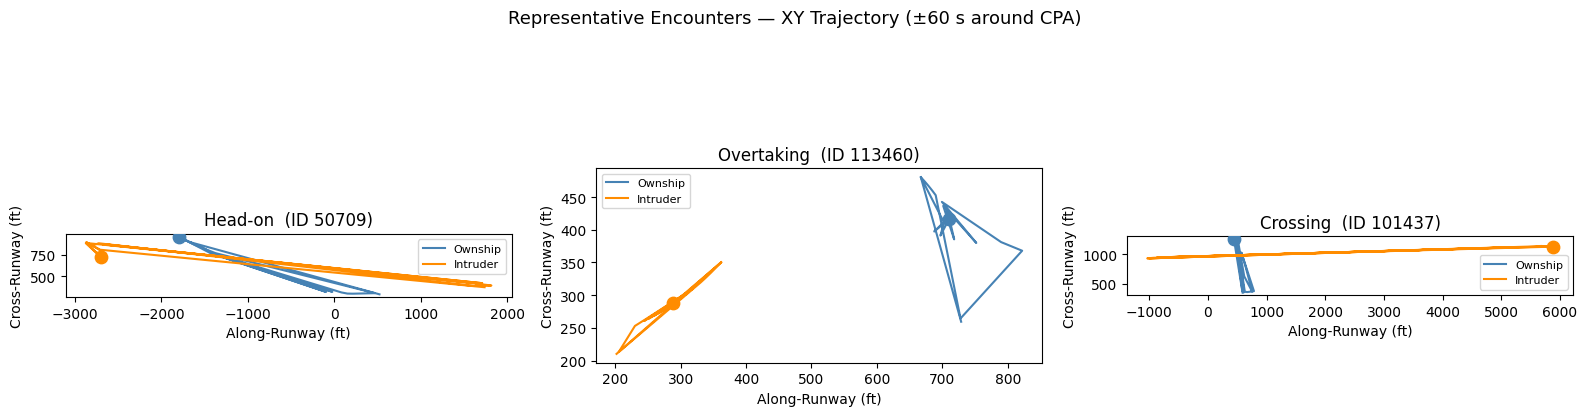

In [10]:
try:
    import h5py
except ImportError:
    raise ImportError("Install with: pip install h5py")

OUTPUT_PATH = 'lltem_sindy_dataset.h5'

# --- Normalization: z-score fitted on training set only ---
# For state x_norm = (x - mu) / sigma  →  its derivative scales as  dx_norm/dt = dx/dt / sigma
# Both X and Ẋ must be on the same normalized scale for SINDy's sparse regression.
norm_params = {}
for var in SINDY_VARS:
    vals = np.concatenate([enc[var] for enc in train_data])
    mu, sigma = float(np.nanmean(vals)), float(np.nanstd(vals))
    norm_params[var] = {'mean': mu, 'std': sigma if sigma > 0 else 1.0}

def apply_norm(enc, params):
    out = dict(enc)
    for var, p in params.items():
        if var in out:
            out[f'{var}_norm'] = (out[var] - p['mean']) / p['std']
        deriv_key = f'd_{var}'
        if deriv_key in out:
            out[f'{deriv_key}_norm'] = out[deriv_key] / p['std']   # derivative scaling
    return out

train_data = [apply_norm(e, norm_params) for e in train_data]
val_data   = [apply_norm(e, norm_params) for e in val_data]

print("Normalization parameters:")
header = f"{'Variable':<20} {'Mean':>12} {'Std':>12}"
print(header + '\n' + '-' * len(header))
for var in SINDY_VARS:
    p = norm_params[var]
    print(f"  {var:<18} {p['mean']:>12.3f} {p['std']:>12.3f}")

# --- Save to HDF5 ---
with h5py.File(OUTPUT_PATH, 'w') as hf:
    for split_name, data in [('train', train_data), ('val', val_data)]:
        grp = hf.create_group(split_name)
        for enc in data:
            eg = grp.create_group(str(enc['encounter_id']))
            eg.attrs['encounter_id'] = enc['encounter_id']
            eg.attrs['geometry']     = enc['geometry']
            for key, val in enc.items():
                if key in ('encounter_id', 'geometry'):
                    continue
                if isinstance(val, np.ndarray):
                    eg.create_dataset(key, data=val.astype(np.float32), compression='gzip')

    ng = hf.create_group('normalization')
    for var, p in norm_params.items():
        vg = ng.create_group(var)
        vg.attrs['mean'] = p['mean']
        vg.attrs['std']  = p['std']

import os
size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
print(f"\nSaved → {OUTPUT_PATH}  ({size_mb:.1f} MB)")
print(f"  /train : {len(train_data):,} encounters")
print(f"  /val   : {len(val_data):,} encounters")

# --- Derivative quality: reconstruction error on 200 training samples ---
print("\n=== Derivative Reconstruction Error (mean |∫ṡ_norm dt − x_norm|) ===")
for var in DERIV_VARS[:6]:
    errors = []
    for enc in train_data[:200]:
        x     = enc.get(f'{var}_norm')
        dx    = enc.get(f'd_{var}_norm')
        if x is None or dx is None:
            continue
        reconstructed = x[0] + np.cumsum(dx) * DT
        errors.append(np.abs(reconstructed - x).mean())
    print(f"  {var:<20} {np.mean(errors):.5f} (normalized units)")

# --- Visualization: representative trajectory per geometry ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Representative Encounters — XY Trajectory (±60 s around CPA)", fontsize=13)

for ax, geom in zip(axes, ['head-on', 'overtaking', 'crossing']):
    enc = next((e for e in train_data if e['geometry'] == geom), None)
    if enc is None:
        ax.set_title(f'{geom.capitalize()} (none found)')
        continue
    cpa_i = np.argmin(np.abs(enc['time']))
    ax.plot(enc['own_x'], enc['own_y'], color='steelblue', label='Ownship')
    ax.plot(enc['int_x'], enc['int_y'], color='darkorange', label='Intruder')
    ax.scatter(enc['own_x'][cpa_i], enc['own_y'][cpa_i], color='steelblue', s=80, zorder=5)
    ax.scatter(enc['int_x'][cpa_i], enc['int_y'][cpa_i], color='darkorange', s=80, zorder=5)
    ax.set_title(f'{geom.capitalize()}  (ID {enc["encounter_id"]})')
    ax.set_xlabel('Along-Runway (ft)')
    ax.set_ylabel('Cross-Runway (ft)')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Step 5: Exploratory Data Analysis & Feature Engineering

### 5.1 Encounter Characterization

Objective: understand encounter dynamics and identify the most relevant features for modeling.

- **Step 1**  geometry distribution and conflict severity statistics  
- **Step 2**  kinematic characterization: state variable distributions at CPA  
- **Step 3**  dominant dynamics: rank variables by derivative activity near CPA  
- **Step 4**  feature importance: correlation with conflict severity

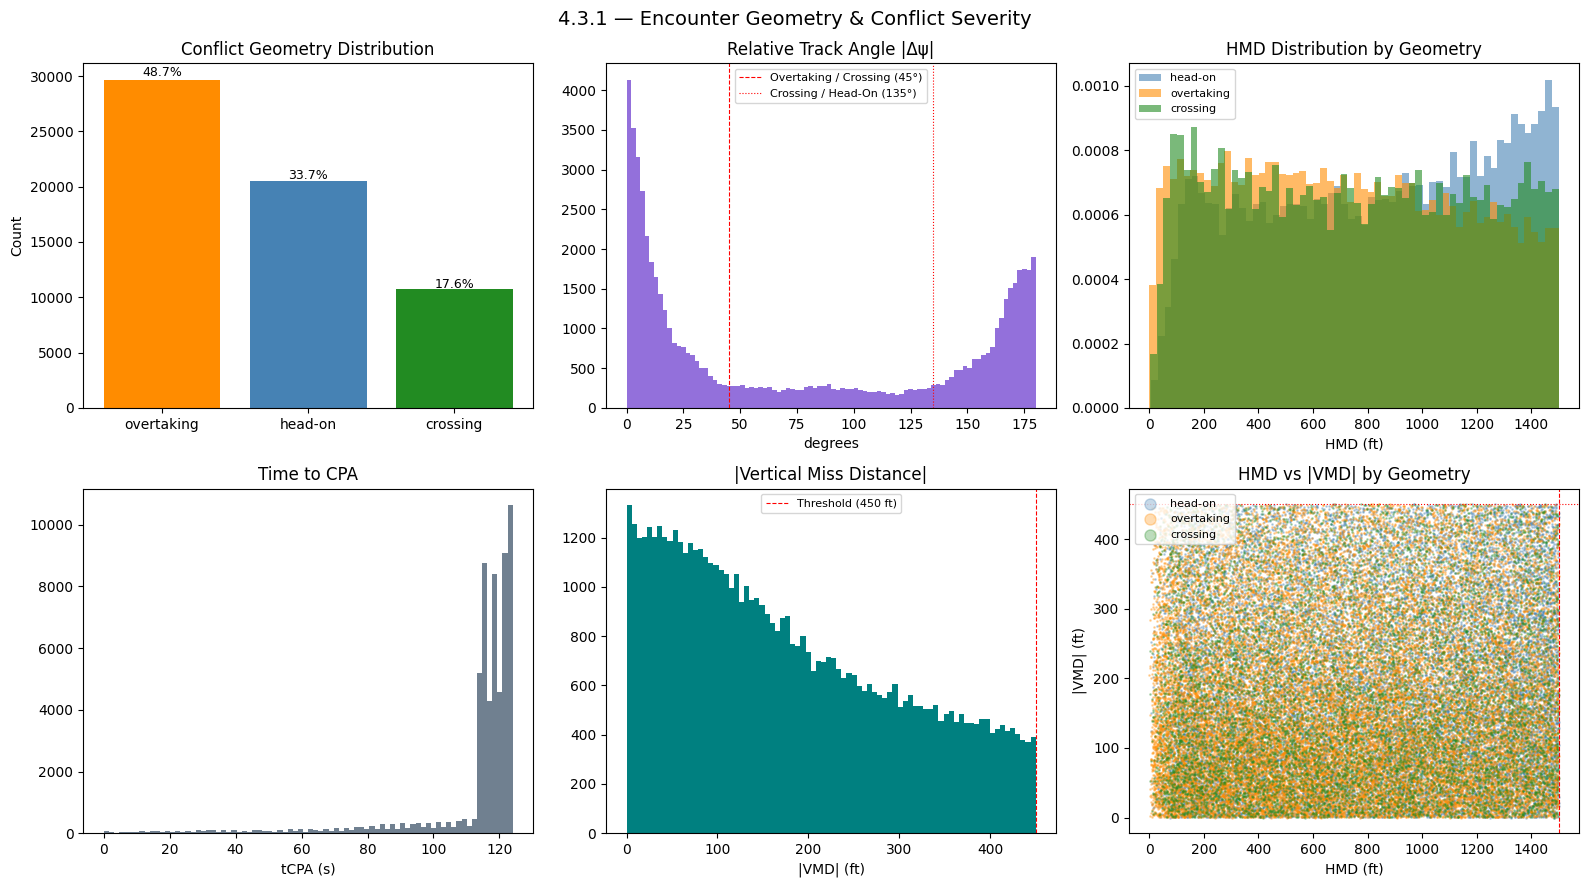


=== Conflict Geometry Summary ===
Geometry         Count      %     Med HMD   Med |VMD|
------------------------------------------------------
  head-on       20,531  33.7%       856 ft       173 ft
  overtaking    29,662  48.7%       700 ft       141 ft
  crossing      10,736  17.6%       746 ft       148 ft


In [11]:
# Step 1: Geometry distribution and conflict severity statistics
# Uses `pool` (all conflict encounters with geometry labels from 4.2.2 Step 1)
# and `conflicts` (HMD+VMD violations from 4.2.1 Step 3).

_colors = {'head-on': 'steelblue', 'overtaking': 'darkorange', 'crossing': 'forestgreen'}
_geom_counts = pool['geometry'].value_counts()
_rel_angles  = pool.apply(
    lambda r: abs((r['int_trk_angle'] - r['own_trk_angle'] + 180) % 360 - 180), axis=1
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("4.3.1 — Encounter Geometry & Conflict Severity", fontsize=14)

# Geometry bar chart
axes[0,0].bar(_geom_counts.index, _geom_counts.values,
              color=[_colors[g] for g in _geom_counts.index])
for i, (g, c) in enumerate(_geom_counts.items()):
    axes[0,0].text(i, c * 1.01, f'{100*c/len(pool):.1f}%', ha='center', fontsize=9)
axes[0,0].set_title('Conflict Geometry Distribution')
axes[0,0].set_ylabel('Count')

# Relative track angle
axes[0,1].hist(_rel_angles, bins=90, color='mediumpurple', edgecolor='none')
axes[0,1].axvline(45,  color='red', linestyle='--', lw=0.8, label='Overtaking / Crossing (45°)')
axes[0,1].axvline(135, color='red', linestyle=':',  lw=0.8, label='Crossing / Head-On (135°)')
axes[0,1].set_title('Relative Track Angle |Δψ|')
axes[0,1].set_xlabel('degrees')
axes[0,1].legend(fontsize=8)

# HMD by geometry (density)
for geom, color in _colors.items():
    sub = pool[pool['geometry'] == geom]
    axes[0,2].hist(sub['hmd_ft'], bins=60, alpha=0.6, color=color, label=geom, density=True)
axes[0,2].set_title('HMD Distribution by Geometry')
axes[0,2].set_xlabel('HMD (ft)')
axes[0,2].legend(fontsize=8)

# tCPA distribution
axes[1,0].hist(conflicts['tcpa'], bins=80, color='slategrey', edgecolor='none')
axes[1,0].set_title('Time to CPA')
axes[1,0].set_xlabel('tCPA (s)')

# |VMD| distribution
axes[1,1].hist(conflicts['vmd_ft'].abs(), bins=80, color='teal', edgecolor='none')
axes[1,1].axvline(450, color='red', linestyle='--', lw=0.8, label='Threshold (450 ft)')
axes[1,1].set_title('|Vertical Miss Distance|')
axes[1,1].set_xlabel('|VMD| (ft)')
axes[1,1].legend(fontsize=8)

# HMD vs |VMD| scatter by geometry
for geom, color in _colors.items():
    sub = pool[pool['geometry'] == geom]
    axes[1,2].scatter(sub['hmd_ft'], sub['vmd_ft'].abs(), s=1, alpha=0.3, color=color, label=geom)
axes[1,2].axvline(HMD_THRESHOLD_FT, color='red', linestyle='--', lw=0.8)
axes[1,2].axhline(VMD_THRESHOLD_FT, color='red', linestyle=':', lw=0.8)
axes[1,2].set_title('HMD vs |VMD| by Geometry')
axes[1,2].set_xlabel('HMD (ft)')
axes[1,2].set_ylabel('|VMD| (ft)')
axes[1,2].legend(markerscale=8, fontsize=8)

plt.tight_layout()
plt.show()

print("\n=== Conflict Geometry Summary ===")
print(f"{'Geometry':<14} {'Count':>7} {'%':>6}  {'Med HMD':>10}  {'Med |VMD|':>10}")
print('-' * 54)
for geom in ['head-on', 'overtaking', 'crossing']:
    sub = pool[pool['geometry'] == geom]
    print(f"  {geom:<12} {len(sub):>7,} {100*len(sub)/len(pool):>5.1f}%  "
          f"{sub['hmd_ft'].median():>8.0f} ft  {sub['vmd_ft'].abs().median():>8.0f} ft")

In [12]:
# Step 2: Kinematic characterization — state variable distributions at CPA (t = 0, index 60)
UNITS = {
    'own_x': 'ft', 'own_y': 'ft', 'own_z': 'ft AGL',
    'own_vx': 'ft/s', 'own_vy': 'ft/s', 'own_vz': 'ft/s',
    'own_psi': 'rad', 'own_gamma': 'rad',
    'int_x': 'ft', 'int_y': 'ft', 'int_z': 'ft AGL',
    'int_vx': 'ft/s', 'int_vy': 'ft/s', 'int_vz': 'ft/s',
    'int_psi': 'rad', 'int_gamma': 'rad',
    'rel_x': 'ft', 'rel_y': 'ft', 'rel_z': 'ft',
    'rel_vx': 'ft/s', 'rel_vy': 'ft/s', 'rel_vz': 'ft/s',
    'range_h': 'ft', 'range_3d': 'ft', 'bearing': 'rad', 'closure_rate': 'ft/s',
}

if not train_data:
    print("Run Section 4.2.2 pipeline first — train_data is empty.")
else:
    _cpa = 60   # t_uniform[-60..+60] → index 60 = t=0 (CPA)

    print("=== State Variable Statistics at CPA (raw units) ===")
    print(f"{'Variable':<22} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}  Unit")
    print('-' * 76)

    for var in SINDY_VARS:
        vals = np.array([e[var][_cpa] for e in train_data
                         if len(e[var]) > _cpa and not np.isnan(e[var][_cpa])])
        if len(vals) == 0:
            continue
        print(f"  {var:<20} {vals.mean():>10.1f} {vals.std():>10.1f} "
              f"{vals.min():>10.1f} {vals.max():>10.1f}  {UNITS.get(var,'')}")

    min_ranges = np.array([e['range_3d'].min() for e in train_data])
    print(f"\n  {'min_range_3d':<20} {min_ranges.mean():>10.1f} {min_ranges.std():>10.1f} "
          f"{min_ranges.min():>10.1f} {min_ranges.max():>10.1f}  ft  (window minimum)")

=== State Variable Statistics at CPA (raw units) ===
Variable                     Mean        Std        Min        Max  Unit
----------------------------------------------------------------------------
  own_x                    -108.4     2143.9   -18855.4    38112.6  ft
  own_y                     870.9      530.8      200.1     2984.7  ft
  own_z                     126.9       38.5     -175.4      184.0  ft AGL
  own_vx                      1.4       33.6     -178.7      180.0  ft/s
  own_vy                     -5.5        4.3      -16.7       11.9  ft/s
  own_vz                      0.0        0.0       -0.1        0.1  ft/s
  own_psi                     0.0        0.2       -0.5        0.5  rad
  own_gamma                   0.0        0.0       -0.3        0.5  rad
  int_x                     157.8     5308.2   -37404.0    42330.9  ft
  int_y                     796.8      412.3      202.3     2896.0  ft
  int_z                      -8.4      149.8     -421.0      421.8  ft AGL


=== Derivative Magnitude Ranking — Mean |ẋ| Across ±60 s Window ===
Rank   Variable                   Mean |ẋ|       Std(ẋ)
--------------------------------------------------------
  1    rel_x                       235.592      847.717
  2    int_x                       226.367      811.815
  3    range_h                     179.127      679.507
  4    range_3d                    178.358      678.393
  5    own_x                        63.147      265.784
  6    own_y                        30.808       89.385
  7    rel_y                        23.463       75.143
  8    int_y                        15.274       50.649
  9    rel_z                         7.496       22.376
  10   int_z                         6.443       19.997
  11   int_vx                        4.648       13.948
  12   own_vx                        2.089        5.947
  13   own_z                         1.882        6.315
  14   own_vy                        0.279        0.775
  15   int_vy                      

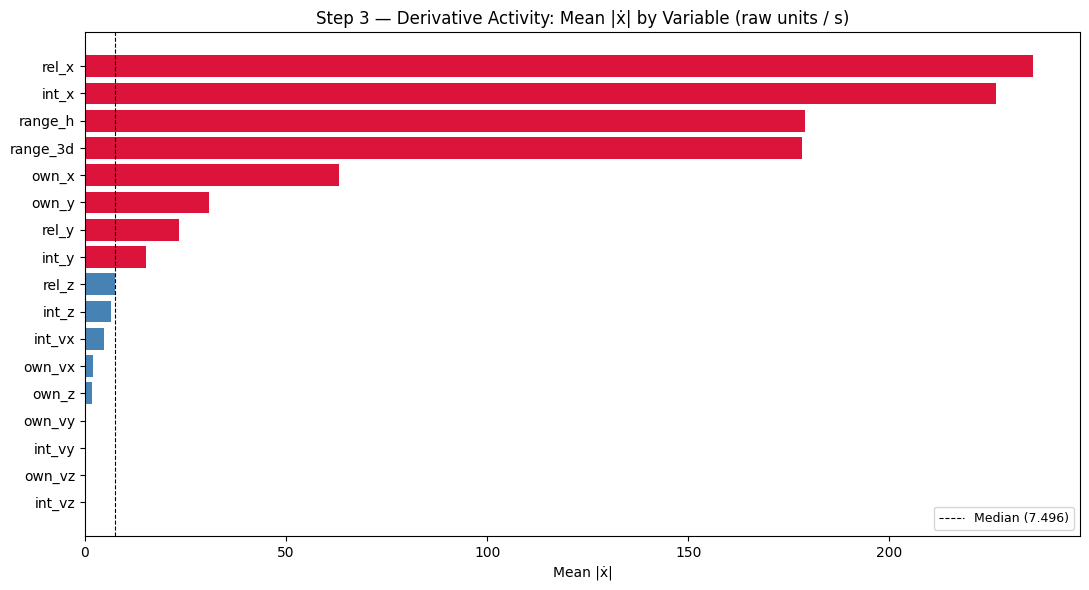

In [13]:
# Step 3: Dominant dynamics — rank state variables by mean |derivative| across ±60s window.
# Variables with highest mean |ẋ| are most dynamically active near CPA.
if not train_data:
    print("Run Section 4.2.2 pipeline first.")
else:
    deriv_stats = {}
    for var in DERIV_VARS:
        key  = f'd_{var}'
        vals = np.concatenate([e[key] for e in train_data if key in e])
        vals = vals[~np.isnan(vals)]
        deriv_stats[var] = {'mean_abs': float(np.mean(np.abs(vals))),
                            'std':      float(np.std(vals))}

    ranked = sorted(deriv_stats.items(), key=lambda x: x[1]['mean_abs'], reverse=True)

    print("=== Derivative Magnitude Ranking — Mean |ẋ| Across ±60 s Window ===")
    print(f"{'Rank':<6} {'Variable':<22} {'Mean |ẋ|':>12}   {'Std(ẋ)':>10}")
    print('-' * 56)
    for rank, (var, s) in enumerate(ranked, 1):
        print(f"  {rank:<4} {var:<22} {s['mean_abs']:>12.3f}   {s['std']:>10.3f}")

    _vars_r   = [v for v, _ in ranked]
    _vals_r   = [s['mean_abs'] for _, s in ranked]
    _med      = float(np.median(_vals_r))

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.barh(_vars_r[::-1], _vals_r[::-1],
            color=['crimson' if v > _med else 'steelblue' for v in _vals_r[::-1]])
    ax.axvline(_med, color='black', linestyle='--', lw=0.8, label=f'Median ({_med:.3f})')
    ax.set_title('Step 3 — Derivative Activity: Mean |ẋ| by Variable (raw units / s)', fontsize=12)
    ax.set_xlabel('Mean |ẋ|')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

=== Feature Importance: |Pearson r| with Minimum 3D Conflict Range ===
Rank   Variable                      r   (bar = |r|)
--------------------------------------------------
  1    range_3d                +0.4652  █████████
  2    range_h                 +0.4651  █████████
  3    int_y                   +0.1999  ███
  4    int_vy                  +0.1717  ███
  5    int_z                   -0.1523  ███
  6    own_z                   -0.1265  ██
  7    rel_z                   -0.1147  ██
  8    own_y                   +0.1069  ██
  9    bearing                 +0.0809  █
  10   own_vy                  +0.0740  █
  11   rel_vy                  +0.0673  █
  12   closure_rate            -0.0626  █
  13   int_vx                  -0.0567  █
  14   rel_y                   +0.0559  █
  15   rel_vx                  -0.0443  
  16   rel_x                   -0.0443  
  17   int_x                   -0.0385  
  18   int_psi                 +0.0319  
  19   own_vx                  -0.0284  
  20   

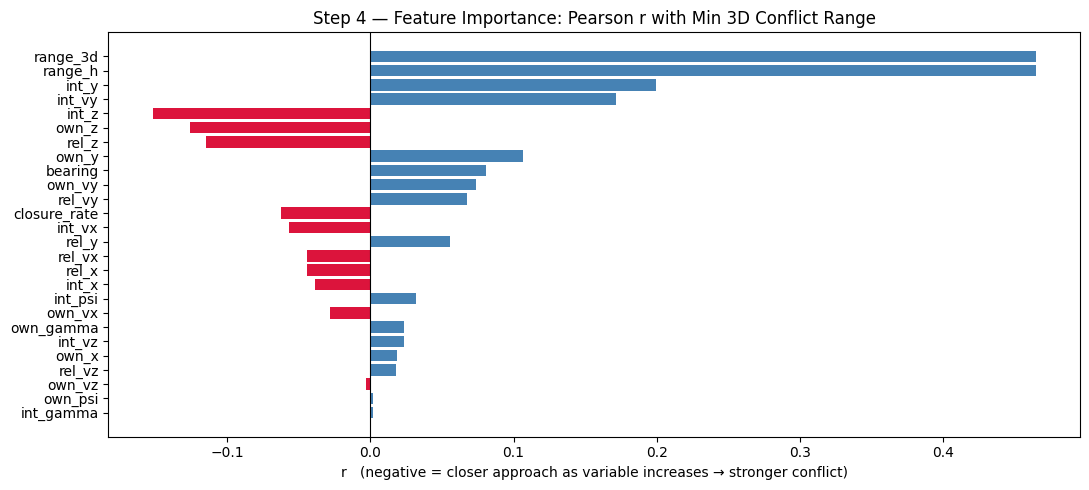

In [14]:
# Step 4: Feature importance — Pearson r between each state variable at CPA
# and the minimum 3D range across the window (conflict severity proxy).
if not train_data:
    print("Run Section 4.2.2 pipeline first.")
else:
    _cpa = 60
    _min_ranges = np.array([e['range_3d'].min() for e in train_data])

    correlations = {}
    for var in SINDY_VARS:
        vals = np.array([e[var][_cpa] for e in train_data if len(e[var]) > _cpa])
        if len(vals) == len(_min_ranges):
            mask = ~np.isnan(vals) & ~np.isnan(_min_ranges)
            if mask.sum() > 10:
                r = float(np.corrcoef(vals[mask], _min_ranges[mask])[0, 1])
                correlations[var] = r

    corr_sorted = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

    print("=== Feature Importance: |Pearson r| with Minimum 3D Conflict Range ===")
    print(f"{'Rank':<6} {'Variable':<22} {'r':>8}   (bar = |r|)")
    print('-' * 50)
    for rank, (var, r) in enumerate(corr_sorted, 1):
        bar = '█' * int(abs(r) * 20)
        print(f"  {rank:<4} {var:<22} {r:>+8.4f}  {bar}")

    fig, ax = plt.subplots(figsize=(11, 5))
    _vars_c = [v for v, _ in corr_sorted]
    _vals_c = [r for _, r in corr_sorted]
    ax.barh(_vars_c[::-1], _vals_c[::-1],
            color=['steelblue' if r >= 0 else 'crimson' for r in _vals_c[::-1]])
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title('Step 4 — Feature Importance: Pearson r with Min 3D Conflict Range', fontsize=12)
    ax.set_xlabel('r   (negative = closer approach as variable increases → stronger conflict)')
    plt.tight_layout()
    plt.show()

### 5.2 Feature Engineering for SINDy

Design the candidate function library Θ(X) for sparse regression: polynomial terms (degree ≤ 2), trigonometric functions for angular states, and interaction terms between ownship and intruder dynamics.

In [15]:
from itertools import combinations_with_replacement
from math import comb as _comb

# ── Physical constraints (LLTEM / DO-365A / Class D airspace) ─────────────────
print("=" * 70)
print("4.3.2 — Library Design: Physics Motivation & Domain Constraints")
print("=" * 70)
print("""
NED Coordinate Convention (x = North, y = East, z = Down):
  Velocity decomposition  →  sin/cos of heading MUST be in the library:
    own_vx = v · cos(ψ_own)    own_vy = v · sin(ψ_own)
    int_vx = v · cos(ψ_int)    int_vy = v · sin(ψ_int)
  Using polynomials to approximate sin/cos converges poorly for headings
  near ±π; exact trig terms are far more parsimonious.

Known kinematic structure — motivates each library term group:
  d(rel_x)/dt      = int_vx − own_vx          → linear: int_vx, own_vx
  d(rel_y)/dt      = int_vy − own_vy          → linear: int_vy, own_vy
  d(range_h)/dt    = −closure_rate            → linear: closure_rate
  d(bearing)/dt    ≈ v_perp / range_h         → sin/cos(bearing) × vel cross-terms
  d(closure)/dt    ≈ (a_own + a_int) · r̂     → quadratic: vel × vel terms
  d(own_psi)/dt    = ψ̇                        → bounded ≤ 0.26 rad/s (15°/s)

Flight dynamics constraints:
  • Ownship (straight-in IFR): constant heading/speed → d(own_psi)/dt ≈ 0
    Near-zero ownship derivatives → strong sparsity signal for STLS
  • Intruder: landing/takeoff, speed 100–220 ft/s, turn rate ≤ 0.26 rad/s
  • All < 3,000 ft AGL → altitude coupling small; 2D horizontal model valid

Exclusions:
  1/range_h   — exact bearing-rate term, but range → 0 at CPA → unstable
                Replaced by bounded proxies: sin(bearing)·closure_rate, etc.
  v³ terms    — cubic velocities unphysical for constant-speed flight legs
                Degree-3 deferred to Phase 3 if deg-2 residuals are large
""")

# ── 2D reduced state ──────────────────────────────────────────────────────────
n_full = len(SINDY_VARS)   # full 26-variable state (defined in 4.2.2)

VARS_2D = [
    'rel_x', 'rel_y',        # relative position (NED, ft)
    'own_vx', 'own_vy',      # ownship velocity components (ft/s)
    'own_psi',               # ownship heading (rad, NED from North)
    'int_vx', 'int_vy',      # intruder velocity components (ft/s)
    'int_psi',               # intruder heading (rad)
    'range_h',               # horizontal range (ft)
    'bearing',               # bearing to intruder (rad)
    'closure_rate',          # rate of approach (ft/s, positive = closing)
]
n_2d = len(VARS_2D)
ANGULAR_VARS = ['own_psi', 'int_psi', 'bearing']

# ── Library function list (name + callable mapping state dict → array) ────────
def build_library_functions(vars_list, angular_vars):
    funcs = []
    funcs.append(('1', lambda s: np.ones(len(s[vars_list[0]]))))
    for v in vars_list:
        funcs.append((v, (lambda v_: lambda s: s[v_])(v)))
    for v1, v2 in combinations_with_replacement(vars_list, 2):
        name = f'{v1}²' if v1 == v2 else f'{v1}·{v2}'
        funcs.append((name, (lambda a, b: lambda s: s[a] * s[b])(v1, v2)))
    for v in angular_vars:
        funcs.append((f'sin({v})', (lambda v_: lambda s: np.sin(s[v_]))(v)))
        funcs.append((f'cos({v})', (lambda v_: lambda s: np.cos(s[v_]))(v)))
    return funcs

LIBRARY_FUNCS = build_library_functions(VARS_2D, ANGULAR_VARS)

n_const  = 1
n_lin    = n_2d
n_quad   = len(list(combinations_with_replacement(VARS_2D, 2)))
n_trig   = 2 * len(ANGULAR_VARS)
TOTAL_2D_LIB = n_const + n_lin + n_quad + n_trig
poly1_2d = n_lin; poly2_2d = n_quad; n_trig_2d = n_trig
trig_flat_2d = [name for name, _ in LIBRARY_FUNCS[n_const + n_lin + n_quad:]]

def count_poly_terms(n_vars, max_degree):
    return sum(_comb(n_vars + d - 1, d) for d in range(1, max_degree + 1))

# ── Term catalogue ────────────────────────────────────────────────────────────
print("── Term Catalogue ────────────────────────────────────────────────────────")
_groups = [
    ("Constant",      LIBRARY_FUNCS[:1]),
    ("Linear",        LIBRARY_FUNCS[1 : 1+n_lin]),
    ("Quadratic",     LIBRARY_FUNCS[1+n_lin : 1+n_lin+n_quad]),
    ("Trigonometric", LIBRARY_FUNCS[1+n_lin+n_quad:]),
]
for gname, items in _groups:
    print(f"\n  [{gname}]  ({len(items)} terms)")
    names = [n for n, _ in items]
    for i in range(0, len(names), 5):
        print("    " + "   ".join(f"{n:<26}" for n in names[i:i+5]))

n_samples_est = len(train_data) * 121 if train_data else 4200 * 121
print(f"\n  {'─'*54}")
print(f"  TOTAL 2D library:  {TOTAL_2D_LIB} terms  ({n_const} const + {n_lin} linear + {n_quad} quadratic + {n_trig} trig)")
print(f"  Samples / term:    ~{n_samples_est // TOTAL_2D_LIB:,}×  (target ≥ 100×  ✓)")
print(f"\n  Full {n_full}-variable state — size comparison:")
for deg in [1, 2, 3]:
    t = 1 + count_poly_terms(n_full, deg) + n_trig
    print(f"    Degree ≤ {deg} + trig:  {t:>6,} terms")

4.3.2 — Library Design: Physics Motivation & Domain Constraints

NED Coordinate Convention (x = North, y = East, z = Down):
  Velocity decomposition  →  sin/cos of heading MUST be in the library:
    own_vx = v · cos(ψ_own)    own_vy = v · sin(ψ_own)
    int_vx = v · cos(ψ_int)    int_vy = v · sin(ψ_int)
  Using polynomials to approximate sin/cos converges poorly for headings
  near ±π; exact trig terms are far more parsimonious.

Known kinematic structure — motivates each library term group:
  d(rel_x)/dt      = int_vx − own_vx          → linear: int_vx, own_vx
  d(rel_y)/dt      = int_vy − own_vy          → linear: int_vy, own_vy
  d(range_h)/dt    = −closure_rate            → linear: closure_rate
  d(bearing)/dt    ≈ v_perp / range_h         → sin/cos(bearing) × vel cross-terms
  d(closure)/dt    ≈ (a_own + a_int) · r̂     → quadratic: vel × vel terms
  d(own_psi)/dt    = ψ̇                        → bounded ≤ 0.26 rad/s (15°/s)

Flight dynamics constraints:
  • Ownship (straight-in 

PCA input: 509,289 samples × 26 variables

=== Cumulative Variance by Number of Components ===
  80% variance → 2 components
  90% variance → 2 components
  95% variance → 3 components
  99% variance → 3 components


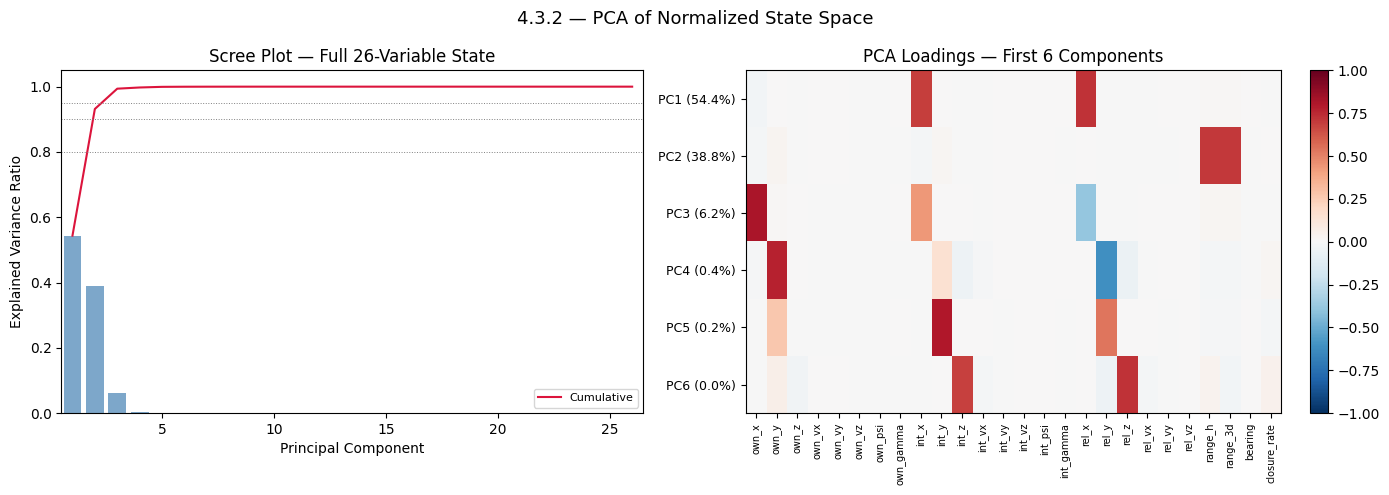


=== Top 5 Variables per Principal Component ===
  PC1 (54.4%): rel_x (+0.720), int_x (+0.694), own_x (-0.026), range_h (+0.009), range_3d (+0.009)
  PC2 (38.8%): range_h (+0.707), range_3d (+0.706), own_y (+0.024), own_x (-0.022), int_x (-0.021)
  PC3 (6.2%): own_x (+0.816), int_x (+0.430), rel_x (-0.386), range_3d (+0.019), range_h (+0.019)


In [16]:
try:
    from sklearn.decomposition import PCA
except ImportError:
    raise ImportError("Install with: pip install scikit-learn")

if not train_data:
    print("Run Section 4.2.2 pipeline first.")
else:
    # Stack all time steps × all training encounters: shape (N_enc × 121, 26)
    X_all = np.vstack([
        np.column_stack([enc[v] for v in SINDY_VARS])
        for enc in train_data
    ])
    valid = ~np.isnan(X_all).any(axis=1)
    X_clean = X_all[valid]
    print(f"PCA input: {X_clean.shape[0]:,} samples × {X_clean.shape[1]} variables")

    pca = PCA()
    pca.fit(X_clean)
    explained = pca.explained_variance_ratio_
    cumvar    = np.cumsum(explained)

    print("\n=== Cumulative Variance by Number of Components ===")
    for threshold in [0.80, 0.90, 0.95, 0.99]:
        n_comp = int(np.searchsorted(cumvar, threshold)) + 1
        print(f"  {threshold*100:.0f}% variance → {n_comp} components")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("4.3.2 — PCA of Normalized State Space", fontsize=13)

    axes[0].bar(range(1, n_full + 1), explained, color='steelblue', alpha=0.7)
    axes[0].plot(range(1, n_full + 1), cumvar, color='crimson', lw=1.5, label='Cumulative')
    for t in [0.80, 0.90, 0.95]:
        axes[0].axhline(t, color='grey', linestyle=':', lw=0.7)
    axes[0].set_xlim([0.5, n_full + 0.5])
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[0].set_title('Scree Plot — Full 26-Variable State')
    axes[0].legend(fontsize=8)

    n_show = 6
    loadings_df = pd.DataFrame(
        pca.components_[:n_show].T,
        index=SINDY_VARS,
        columns=[f'PC{i+1}' for i in range(n_show)]
    )
    im = axes[1].imshow(loadings_df.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    axes[1].set_xticks(range(n_full))
    axes[1].set_xticklabels(SINDY_VARS, rotation=90, fontsize=7)
    axes[1].set_yticks(range(n_show))
    axes[1].set_yticklabels(
        [f'PC{i+1} ({100*explained[i]:.1f}%)' for i in range(n_show)], fontsize=9)
    axes[1].set_title(f'PCA Loadings — First {n_show} Components')
    plt.colorbar(im, ax=axes[1], fraction=0.03)
    plt.tight_layout()
    plt.show()

    print("\n=== Top 5 Variables per Principal Component ===")
    for pc_idx in range(3):
        top_idx  = np.argsort(np.abs(pca.components_[pc_idx]))[::-1][:5]
        top_vars = [(SINDY_VARS[i], float(pca.components_[pc_idx][i])) for i in top_idx]
        top_str  = ', '.join(f'{v} ({r:+.3f})' for v, r in top_vars)
        print(f"  PC{pc_idx+1} ({100*explained[pc_idx]:.1f}%): {top_str}")

Library matrix Θ(X) shape: (121, 84)  (timesteps × library terms)
  Non-finite entries:  0  âœ“
  Condition number κ:  2.17e+24  HIGH — correlated features
  (κ < 1e6 comfortable for STLS; κ > 1e8 → consider column pivoting or SR3)

  Low-variance terms (var < 1e-4 — likely pruned first by STLS threshold):
    1 (0.0e+00), int_psi (1.1e-05), own_psi·int_psi (4.0e-07), int_psi² (5.1e-10), int_psi·bearing (9.4e-05), sin(int_psi) (1.1e-05), cos(int_psi) (1.3e-10)


C:\Users\adria\AppData\Local\Temp\ipykernel_24712\2720295674.py:35: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adria\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


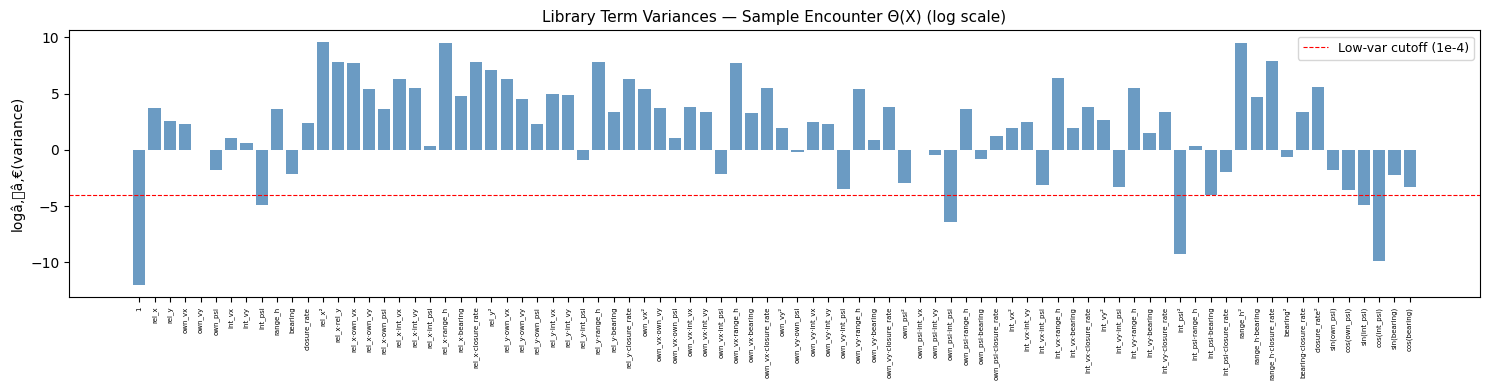

In [17]:
# ── Build Θ(X) for a sample encounter and validate ────────────────────────────
if not train_data:
    print("Run Section 4.2.2 first.")
else:
    sample     = train_data[0]
    Theta      = np.column_stack([fn(sample) for _, fn in LIBRARY_FUNCS])
    term_names = [name for name, _ in LIBRARY_FUNCS]

    print(f"Library matrix Θ(X) shape: {Theta.shape}  (timesteps × library terms)")
    n_bad = (~np.isfinite(Theta)).sum()
    print(f"  Non-finite entries:  {n_bad}  {'âœ“' if n_bad == 0 else 'â† fix inputs'}")

    Theta_fin = Theta[np.isfinite(Theta).all(axis=1)]
    cond      = np.linalg.cond(Theta_fin)
    flag      = '✓  (< 1e6)' if cond < 1e6 else ('warn  (> 1e6)' if cond < 1e10 else 'HIGH — correlated features')
    print(f"  Condition number κ:  {cond:.2e}  {flag}")
    print(f"  (κ < 1e6 comfortable for STLS; κ > 1e8 → consider column pivoting or SR3)")

    # Low-variance terms
    term_var = np.var(Theta_fin, axis=0)
    low_var  = [(term_names[i], term_var[i]) for i in range(len(term_names)) if term_var[i] < 1e-4]
    print(f"\n  Low-variance terms (var < 1e-4 — likely pruned first by STLS threshold):")
    print("    " + (", ".join(f"{n} ({v:.1e})" for n, v in low_var) if low_var else "None ✓"))

    # Term variance bar chart
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.bar(range(len(term_names)), np.log10(np.maximum(term_var, 1e-12)),
           color='steelblue', alpha=0.8)
    ax.axhline(-4, color='red', linestyle='--', lw=0.8, label='Low-var cutoff (1e-4)')
    ax.set_xticks(range(len(term_names)))
    ax.set_xticklabels(term_names, rotation=90, fontsize=5)
    ax.set_ylabel('logâ‚â‚€(variance)')
    ax.set_title('Library Term Variances — Sample Encounter Θ(X) (log scale)', fontsize=11)
    ax.legend(fontsize=9)
    plt.tight_layout() 
    plt.show()


## Step 6: Model Development